In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,zara aavaas,sector 104,0.2,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,not available,3.0,NaN,0 to 1 Year Old,"['Ardee Mall', 'Northern Peripheral Road', 'Mps World School', 'DPG Institute of Technology', 'Tomar Hospital', 'Indira Gandhi International Airport', 'Taj City Centre Hotel', ""Oyster's Water Park"", 'HUDA Mini Golf Course', 'F9 Go Karting Gurgaon']",[],NaN


In [5]:
# 1. areaWithType
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
2208,0.40,432.0,Plot area 432(40.13 sq.m.)
2968,2.45,1531.0,Built Up area: 1200 (111.48 sq.m.)Carpet area: 1000 sq.ft. (92.9 sq.m.)
1160,3.75,1467.0,Built Up area: 163 (136.29 sq.m.)
799,2.40,2086.0,Super Built up area 2086(193.8 sq.m.)
1213,0.90,2000.0,Built Up area: 2000 (185.81 sq.m.)


In [6]:
# To extract the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None
# To extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None
# To checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [7]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(lambda x: get_super_built_up_area(x) if pd.notna(x) and isinstance(x, str) else None)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']) if pd.notna(x['areaWithType']) and isinstance(x['areaWithType'], str) and pd.notna(x['super_built_up_area']) else x['super_built_up_area'], axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area') if pd.notna(x) and isinstance(x, str) else None)
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']) if pd.notna(x['areaWithType']) and isinstance(x['areaWithType'], str) and pd.notna(x['built_up_area']) else x['built_up_area'], axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area') if pd.notna(x) and isinstance(x, str) else None)
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']) if pd.notna(x['areaWithType']) and isinstance(x['areaWithType'], str) and pd.notna(x['carpet_area']) else x['carpet_area'], axis=1)

In [8]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2510,1.20,flat,970.0,Super Built up area 1671(155.24 sq.m.)Built Up area: 1190 sq.ft. (110.55 sq.m.)Carpet area: 970 sq.ft. (90.12 sq.m.),1671.0,1190.0,970.0
3730,2.20,flat,1760.0,Carpet area: 1760 (163.51 sq.m.),NaN,NaN,1760.0
814,0.70,flat,1326.0,Super Built up area 1326(123.19 sq.m.)Built Up area: 1325 sq.ft. (123.1 sq.m.)Carpet area: 1320 sq.ft. (122.63 sq.m.),1326.0,1325.0,1320.0
2448,0.65,flat,1050.0,Carpet area: 1050 (97.55 sq.m.),NaN,NaN,1050.0
3364,2.28,flat,2600.0,Super Built up area 3434(319.03 sq.m.)Carpet area: 2600 sq.ft. (241.55 sq.m.),3434.0,NaN,2600.0


In [9]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [10]:
#handling NaN values with na=False parameter
df[df['areaWithType'].str.contains('Plot', na=False)][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
7,2.65,house,1400.0,Plot area 2160(200.67 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),NaN,1800.0,1400.0
12,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
16,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
17,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
20,7.49,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [11]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    67
price_per_sqft           27
area                     67
areaWithType             49
bedRoom                  49
bathroom                 49
balcony                  49
additionalRoom            0
floorNum                 68
facing                 1154
agePossession            50
nearbyLocations         185
furnishDetails         1030
features                684
super_built_up_area    1937
built_up_area          2665
carpet_area            1908
dtype: int64

In [12]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [13]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
12,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
15,NaN,house,NaN,NaN,NaN,NaN,NaN
16,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
17,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
20,7.49,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [14]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [15]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [16]:
# Filter out NaN values before applying the function
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(
    lambda x: extract_plot_area(x) if pd.notna(x) else None
)

# Alternative approach: Fill NaN values with empty string first
# all_nan_df['built_up_area'] = all_nan_df['areaWithType'].fillna('').apply(extract_plot_area)
# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [17]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
12,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
15,NaN,house,NaN,NaN,NaN,NaN,NaN
16,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,520.00,NaN
17,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
20,7.49,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
21,NaN,house,NaN,NaN,NaN,NaN,NaN
31,9.40,house,3600.0,Plot area 400(334.45 sq.m.),NaN,400.00,NaN
38,7.05,house,1503.0,Plot area 167(139.63 sq.m.),NaN,167.00,NaN
44,3.90,house,1836.0,Plot area 204(170.57 sq.m.),NaN,204.00,NaN
45,3.30,house,2250.0,Plot area 250(209.03 sq.m.),NaN,250.00,NaN


In [18]:
# update the original dataframe
df.update(all_nan_df)

In [19]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    67
price_per_sqft           27
area                     67
areaWithType             49
bedRoom                  49
bathroom                 49
balcony                  49
additionalRoom            0
floorNum                 68
facing                 1154
agePossession            50
nearbyLocations         185
furnishDetails         1030
features                684
super_built_up_area    1937
built_up_area          2119
carpet_area            1908
dtype: int64

In [20]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,not available,3.0,NaN,0 to 1 Year Old,"['Ardee Mall', 'Northern Peripheral Road', 'Mps World School', 'DPG Institute of Technology', 'Tomar Hospital', 'Indira Gandhi International Airport', 'Taj City Centre Hotel', ""Oyster's Water Park"", 'HUDA Mini Golf Course', 'F9 Go Karting Gurgaon']",[],NaN,NaN,NaN,301.0
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,not available,1.0,South-West,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Esic Hospital Gurugram', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1350.0,NaN,NaN
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,not available,3.0,NaN,By 2023,"['Raheja Mall', 'HUDA Market, Sector 14', 'Gurgaon Road', 'Dwarka Expressway', 'RHM Public School', 'SGT University', 'Shri Balaji Multispeciality Hospital', 'Indira Gandhi International Airport', 'infinity Business Park', 'Park Inn, Gurgaon', 'Heritage badminton academy', 'SkyJumper Trampoline Park']",[],NaN,1440.0,NaN,NaN
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up area: 2791 sq.ft. (259.29 sq.m.)Carpet area: 2768 sq.ft. (257.16 sq.m.),4.0,5.0,3,Servant Room,15.0,East,5 to 10 Year Old,"['Sector 55-56 Metro', 'Golf Course Extension', 'Adarsh Senior Secondary School', 'Swastik Hospital Sec 66', 'IGI Airport', 'Surajgarh Gurgaon, Golf Course Ext Rd', 'International Tech Park Gurgaon,']","['4 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '4 Geyser', '10 Light', '6 AC', '1 Modular Kitchen', '1 Curtains', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Fitness Centre / GYM', 'Club house / Community Center']",2800.0,2791.0,2768.0
4,flat,breez global heights,sector 36,0.24,5825.0,412.0,Carpet area: 412 (38.28 sq.m.),1.0,1.0,1,not available,8.0,NaN,0 to 1 Year Old,"['S.R.S. Hospital and Critical Care Unit', 'Shri Balaji Hospital and Trauma Center', 'Chandna Dental Surgery Orthodontic and Implant Centre', 'The Muskan Dental Clinic', 'Dental Xpert Dental Clinic', 'Ayushman Hospital And Trauma Centre', 'Yadav Hospital Gurgoan', 'Kamla Hospital Gurgaon', 'Harshila Dental Clinic', 'Clove Dental', 'Vaishnavi Nursing Home', 'Petrol Pump IBP', 'Petrol Pump Indian Oil', 'Boxer Fuel Point', 'Haldiram']","['1 Wardrobe', '2 Fan', '1 Exhaust Fan', '5 Light', '1 Modular Kitchen', '1 Curtains', 'No AC', 'No Bed', 'No Chimney', 'No Dining Tab

In [21]:
# 2.additionalRoom
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1636
Servant Room                                      705
Study Room                                        250
Others                                            225
Pooja Room                                        165
Store Room                                         99
Study Room,Servant Room                            99
Pooja Room,Servant Room                            82
Pooja Room,Study Room,Servant Room,Store Room      72
Servant Room,Others                                60
Pooja Room,Study Room,Servant Room                 55
Pooja Room,Study Room,Servant Room,Others          54
Servant Room,Pooja Room                            38
Servant Room,Store Room                            33
Study Room,Others                                  29
Pooja Room,Study Room                              22
Pooja Room,Others                                  17
Pooja Room,Store Room                              15
Pooja Room,St

In [29]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col, case=False, na=False).astype(int)

In [30]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
101,Servant Room,0,1,0,0,0
350,Servant Room,0,1,0,0,0
210,not available,0,0,0,0,0
2327,Study Room,1,0,0,0,0
3542,Servant Room,0,1,0,0,0


In [31]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,not available,3.0,NaN,0 to 1 Year Old,"['Ardee Mall', 'Northern Peripheral Road', 'Mps World School', 'DPG Institute of Technology', 'Tomar Hospital', 'Indira Gandhi International Airport', 'Taj City Centre Hotel', ""Oyster's Water Park"", 'HUDA Mini Golf Course', 'F9 Go Karting Gurgaon']",[],NaN,NaN,NaN,301.0,0,0,0,0,0
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,not available,1.0,South-West,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Esic Hospital Gurugram', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1350.0,NaN,NaN,0,0,0,0,0
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,not available,3.0,NaN,By 2023,"['Raheja Mall', 'HUDA Market, Sector 14', 'Gurgaon Road', 'Dwarka Expressway', 'RHM Public School', 'SGT University', 'Shri Balaji Multispeciality Hospital', 'Indira Gandhi International Airport', 'infinity Business Park', 'Park Inn, Gurgaon', 'Heritage badminton academy', 'SkyJumper Trampoline Park']",[],NaN,1440.0,NaN,NaN,0,0,0,0,0
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up area: 2791 sq.ft. (259.29 sq.m.)Carpet area: 2768 sq.ft. (257.16 sq.m.),4.0,5.0,3,Servant Room,15.0,East,5 to 10 Year Old,"['Sector 55-56 Metro', 'Golf Course Extension', 'Adarsh Senior Secondary School', 'Swastik Hospital Sec 66', 'IGI Airport', 'Surajgarh Gurgaon, Golf Course Ext Rd', 'International Tech Park Gurgaon,']","['4 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '4 Geyser', '10 Light', '6 AC', '1 Modular Kitchen', '1 Curtains', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Fitness Centre / GYM', 'Club house / Community Center']",2800.0,2791.0,2768.0,0,1,0,0,0
4,flat,breez global heights,sector 36,0.24,5825.0,412.0,Carpet area: 412 (38.28 sq.m.),1.0,1.0,1,not available,8.0,NaN,0 to 1 Year Old,"['S.R.S. Hospital and Critical Care Unit', 'Shri Balaji Hospital and Trauma Center', 'Chandna Dental Surgery Orthodontic and Implant Centre', 'The Muskan Dental Clinic', 'Dental Xpert Dental Clinic', 'Ayushman Hospital And Trauma Centre', 'Yadav Hospital Gurgoan', 'Kamla Hospital Gurgaon', 'Harshila Dental Clinic', 'Clove Dental', 'Vaishnavi Nursing Home', 'Petrol Pump IBP', 'Petrol Pump Indian Oil', 'Boxer Fuel Point', 'Haldiram']","['1 Wardrobe', '2 Fan', '1 Exhaust Fan', 

In [32]:
# 3.agePossession
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Nov 2023                 5
Jul 2024                 4
By 2025                  4
Oct 2023                 4
Sep 2023                 4
Aug 2024                 4
Jan 2025                 3
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Jan 2026                 2
Jul 2025                 2
Dec 2026                 2
Apr 2026                 2
Jul 2027                 2
By 2027                  2
Sep 2025                 2
Mar 2025                 2
Jun 2027      

In [33]:
def categorize_age_possession(value):
    if pd.isna(value) or str(value).strip().lower() in ("nan", "none", "", "undefined"):
        return "Undefined"
    
    value = str(value).strip()
    
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [34]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [35]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              382
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [36]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,not available,3.0,NaN,New Property,"['Ardee Mall', 'Northern Peripheral Road', 'Mps World School', 'DPG Institute of Technology', 'Tomar Hospital', 'Indira Gandhi International Airport', 'Taj City Centre Hotel', ""Oyster's Water Park"", 'HUDA Mini Golf Course', 'F9 Go Karting Gurgaon']",[],NaN,NaN,NaN,301.0,0,0,0,0,0
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,not available,1.0,South-West,Relatively New,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Esic Hospital Gurugram', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1350.0,NaN,NaN,0,0,0,0,0
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,not available,3.0,NaN,Under Construction,"['Raheja Mall', 'HUDA Market, Sector 14', 'Gurgaon Road', 'Dwarka Expressway', 'RHM Public School', 'SGT University', 'Shri Balaji Multispeciality Hospital', 'Indira Gandhi International Airport', 'infinity Business Park', 'Park Inn, Gurgaon', 'Heritage badminton academy', 'SkyJumper Trampoline Park']",[],NaN,1440.0,NaN,NaN,0,0,0,0,0
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up area: 2791 sq.ft. (259.29 sq.m.)Carpet area: 2768 sq.ft. (257.16 sq.m.),4.0,5.0,3,Servant Room,15.0,East,Moderately Old,"['Sector 55-56 Metro', 'Golf Course Extension', 'Adarsh Senior Secondary School', 'Swastik Hospital Sec 66', 'IGI Airport', 'Surajgarh Gurgaon, Golf Course Ext Rd', 'International Tech Park Gurgaon,']","['4 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '4 Geyser', '10 Light', '6 AC', '1 Modular Kitchen', '1 Curtains', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Fitness Centre / GYM', 'Club house / Community Center']",2800.0,2791.0,2768.0,0,1,0,0,0
4,flat,breez global heights,sector 36,0.24,5825.0,412.0,Carpet area: 412 (38.28 sq.m.),1.0,1.0,1,not available,8.0,NaN,New Property,"['S.R.S. Hospital and Critical Care Unit', 'Shri Balaji Hospital and Trauma Center', 'Chandna Dental Surgery Orthodontic and Implant Centre', 'The Muskan Dental Clinic', 'Dental Xpert Dental Clinic', 'Ayushman Hospital And Trauma Centre', 'Yadav Hospital Gurgoan', 'Kamla Hospital Gurgaon', 'Harshila Dental Clinic', 'Clove Dental', 'Vaishnavi Nursing Home', 'Petrol Pump IBP', 'Petrol Pump Indian Oil', 'Boxer Fuel Point', 'Haldiram']","['1 Wardrobe', '2 Fan', '1 Exhaust Fan'

In [37]:
# 4.furnishDetails
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1403,[],NaN
794,NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3157,NaN,NaN
545,"['1 Water Purifier', '2 Fan', '1 Fridge', '1 Geyser', '8 Light', '1 AC', '8 Curtains', '1 Modular Kitchen', '1 Wardrobe', 'No Bed', 'No Chimney', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1328,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Geyser', '4 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"


In [38]:
# Extracting all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [39]:
furnishings_df.shape

(3852, 19)

In [40]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\anish\AppData\Local\Temp\ipykernel_29824\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [41]:
furnishings_df.sample(5)

,Bed,Water Purifier,TV,Geyser,Wardrobe,Fan,Microwave,Light,Fridge,Sofa,Dining Table,Chimney,Modular Kitchen,AC,Stove,Washing Machine,Curtains,Exhaust Fan
667,0,1,0,3,3,5,0,19,0,0,0,1,1,4,1,0,7,1
1390,0,0,0,1,2,5,0,5,0,0,0,1,1,4,0,0,0,0
2852,0,0,0,0,4,8,0,20,0,0,0,1,1,5,0,0,0,1
2727,0,0,0,3,3,7,0,11,0,0,0,1,1,0,0,0,1,1
1339,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [42]:
# applying K means clustering to make clusters of items and can call the property unfurnished , semifurnished and furnished
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [44]:
wcss_reduced = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

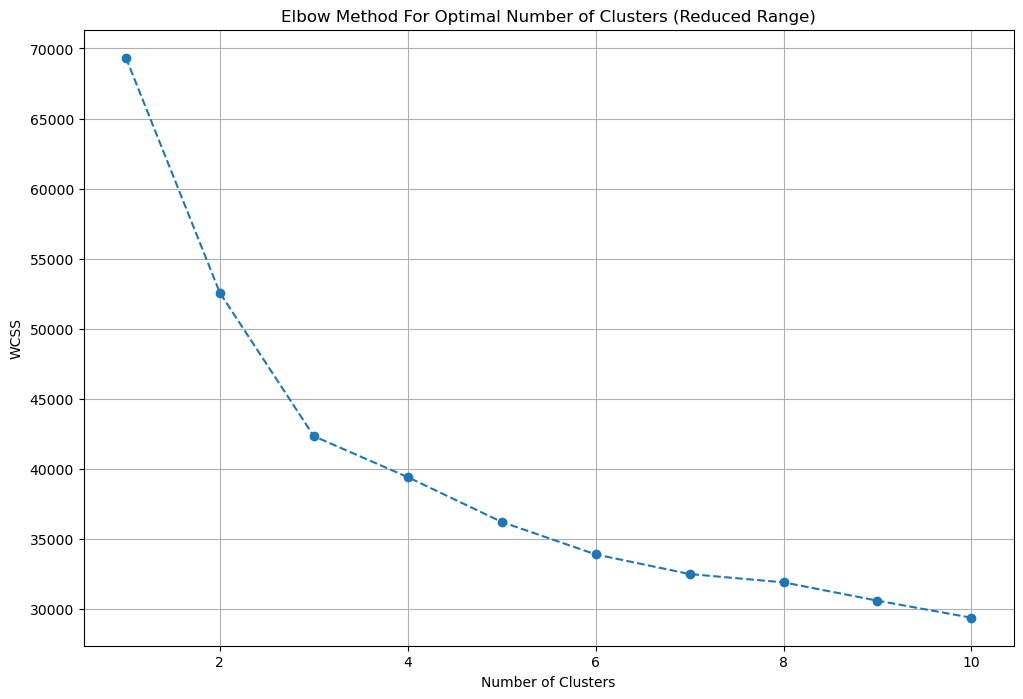

In [45]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [46]:
# from cluster we can say that k = 3
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [47]:
df = df.iloc[:,:-18]

In [48]:
df['furnishing_type'] = cluster_assignments

In [49]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1779,NaN,0
733,"['4 Wardrobe', '3 Fan', '1 Geyser', '1 Microwave', '1 Stove', '10 Light', '1 Chimney', '1 Modular Kitchen', '5 Curtains', '7 AC', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
497,[],0
1678,NaN,0
732,"['6 Fan', '1 Exhaust Fan', '6 Light', '8 AC', '1 Chimney', '1 Modular Kitchen', '4 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2


In [50]:
# 5.features
df[['society','features']].sample(5)

,society,features
3664,experion windchants,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
853,central park flower valley,"['Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1382,m3m heights,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
418,godrej oasis,"['Water purifier', 'No open drainage around', 'Recently Renovated', 'Bank Attached Property', 'Swimming Pool', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
2360,m3m soulitude,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [51]:
df['features'].isnull().sum()

np.int64(684)

In [52]:
# to fill up the missing values it merged the appartments.csv data of society with features of this dataset and wherever the value is nan it automaticallly fills it
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [53]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [54]:
temp_df = df[df['features'].isnull()]

In [55]:
temp_df.shape

(684, 26)

In [56]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [57]:
df.loc[temp_df.index,'features'] = x.values

In [58]:
df['features'].isnull().sum()

np.int64(496)

In [59]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [60]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [61]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theater Home,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1975,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2941,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2704,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3109,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3325,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0


In [62]:
features_binary_df.shape

(3852, 131)

In [63]:
# tried the same approach of creating new columns for each feature and then clustering them but failed later
# new approach that used is to score each property on the basis of its features ex: 10,20,15 etc

In [64]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [65]:
df['luxury_score'] = luxury_score

In [66]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,zara aavaas,sector 104,0.20,6644.0,301.0,Carpet area: 301 (27.96 sq.m.),1.0,2.0,2,not available,3.0,NaN,New Property,"['Ardee Mall', 'Northern Peripheral Road', 'Mps World School', 'DPG Institute of Technology', 'Tomar Hospital', 'Indira Gandhi International Airport', 'Taj City Centre Hotel', ""Oyster's Water Park"", 'HUDA Mini Golf Course', 'F9 Go Karting Gurgaon']",[],"['Swimming Pool', 'Reading Lounge', 'Card Room', 'Sauna', 'Steam Room', 'Cafeteria', 'Billiards', 'Shopping Centre', 'Basketball Court']",NaN,NaN,301.0,0,0,0,0,0,0,"[Swimming Pool, Reading Lounge, Card Room, Sauna, Steam Room, Cafeteria, Billiards, Shopping Centre, Basketball Court]",67
1,flat,landmark the residency,sector 103,0.90,6666.0,1350.0,Super Built up area 1350(125.42 sq.m.),2.0,2.0,2,not available,1.0,South-West,Relatively New,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardwaj Hospital', 'R K Hospital Gurgaon', 'Chirag Hospital Pvt. Ltd', 'Shree Krishna Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Esic Hospital Gurugram', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1350.0,NaN,NaN,0,0,0,0,0,0,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",44
2,flat,ramprastha city,dwarka expressway,1.30,9027.0,1440.0,Super Built up area 1440(133.78 sq.m.),3.0,3.0,2,not available,3.0,NaN,Under Construction,"['Raheja Mall', 'HUDA Market, Sector 14', 'Gurgaon Road', 'Dwarka Expressway', 'RHM Public School', 'SGT University', 'Shri Balaji Multispeciality Hospital', 'Indira Gandhi International Airport', 'infinity Business Park', 'Park Inn, Gurgaon', 'Heritage badminton academy', 'SkyJumper Trampoline Park']",[],NaN,1440.0,NaN,NaN,0,0,0,0,0,0,[],0
3,flat,ireo skyon,sector 60,3.80,13571.0,2800.0,Super Built up area 2800(260.13 sq.m.)Built Up area: 2791 sq.ft. (259.29 sq.m.)Carpet area: 2768 sq.ft. (257.16 sq.m.),4.0,5.0,3,Servant Room,15.0,East,Moderately Old,"['Sector 55-56 Metro', 'Golf Course Extension', 'Adarsh Senior Secondary School', 'Swastik Hospital Sec 66', 'IGI Airport', 'Surajgarh Gurgaon, Golf Course Ext Rd', 'International Tech Park Gurgaon,']","['4 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '4 Geyser', '10 Light', '6 AC', '1 Modular Kitchen', '1 Curtains', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Fitness Centre / GYM', 'Club house / Community Center']",2800.0,2791.0,2768.0,0,1,0,0,0,2,"[Centrally Air Conditioned, Security / Fire Alarm, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, Water Storage, Separate entry f

In [67]:
# as the dataset is mostly cleaned
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [68]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3751,flat,brisk lumbini terrace homes,sector 109,1.38,6338.0,2177.0,Carpet area: 2177 (202.25 sq.m.),3.0,3.0,1,4.0,NaN,Moderately Old,NaN,NaN,2177.0,0,0,0,0,0,0,20
576,house,independent,sector 46,3.55,24500.0,1449.0,Plot area 161(134.62 sq.m.),5.0,4.0,3+,3.0,North-West,Moderately Old,NaN,161.0,NaN,0,1,0,0,0,2,73
1290,flat,signature global park,sohna road,0.54,7248.0,745.0,Carpet area: 745 (69.21 sq.m.),2.0,1.0,3,1.0,NaN,New Property,NaN,NaN,745.0,0,0,0,0,0,0,65
2565,house,mian wali,sector 12,1.70,9444.0,1800.0,Plot area 1800(167.23 sq.m.),1.0,1.0,1,1.0,NaN,Old Property,NaN,1800.0,NaN,0,1,0,0,0,0,7
28,flat,sare green parc 2,sector 92,0.61,4837.0,1261.0,Super Built up area 1261(117.15 sq.m.),3.0,2.0,2,6.0,NaN,Under Construction,1261.0,NaN,NaN,0,0,0,0,1,0,0


In [69]:
df.shape

(3852, 23)

In [71]:
# converted into new fresh dataset
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)